# 17.2: Value Iteration

In [2]:
!pip install gym

     ---------------------------------------- 0.0/721.7 kB ? eta -:--:--
     -------------------------------------- 721.7/721.7 kB 4.2 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for gym: filename=gym-0.26.2-py3-none-any.whl size=827741 sha256=fce60a86136ab212aa41b0f24aca1caedf7d82caf00ea3dcc19b03bcbf44dc90
  Stored in directory: c:\users\py torch\appdata\local\pip\cache\wheels\af\2b\30\5e78b8b9599f2a2286a582b8da80594f654bf0e18d825a4405
Successfully built gym

   -------------------------- ------------- 2/3 [gym]
   -------------------------- ------------- 2/3 [gym]
   -------------------------- ------------- 2/3 [gym]
   -------------------------- ------------- 2/3 [gym]

Using own code since d2l package is broken

In [9]:
import gym
import numpy as np
from d2l import torch as d2l

seed = 0 # Random number generator seed
gamma = 0.95 # Discount factor
num_iters = 10 # Number of iterations
np.random.seed(seed)

# Create environment directly
env = gym.make('FrozenLake-v1', is_slippery=False, desc=None, map_name="4x4")
env.reset()

# You'll need to manually create env_info with the required structure
# This depends on what the value_iteration function expects
env_info = {
    'desc': env.desc if hasattr(env, 'desc') else None,
    'trans_prob_idx': 0,  # Adjust based on actual MDP structure
    'nextstate_idx': 1,
    'reward_idx': 2,
    'num_states': env.observation_space.n,
    'num_actions': env.action_space.n,
    'mdp': {}  # You'll need to build this from env.P
}

# Build MDP transition dictionary
mdp = {}
for s in range(env_info['num_states']):
    for a in range(env_info['num_actions']):
        mdp[(s, a)] = []
        transitions = env.P[s][a]
        for trans in transitions:
            prob, next_state, reward, done = trans
            mdp[(s, a)].append((prob, next_state, reward, done))

env_info['mdp'] = mdp

In FrozenLake environment, the robot moves on a 4x4 grid (these are the states) with actions of up, down, left, and right. Environment contains some holes (H) and frozen (F) cells as well as a goal cell (G), all unknown to the robot.

For simplicity, we assume the robot has reliable actions ($P(s'|s,a)=1 \ \forall s \in S, a \in A$). If the robot reaches its goal, the trial ends and the robot receives a reward of 1 irrespective of the action; the reward at any other state is 0 for all actions.

The objective of the robot is to learn a policy that reaches the goal location (G) from a given start location S (this is $s_0$) to maximize the return.

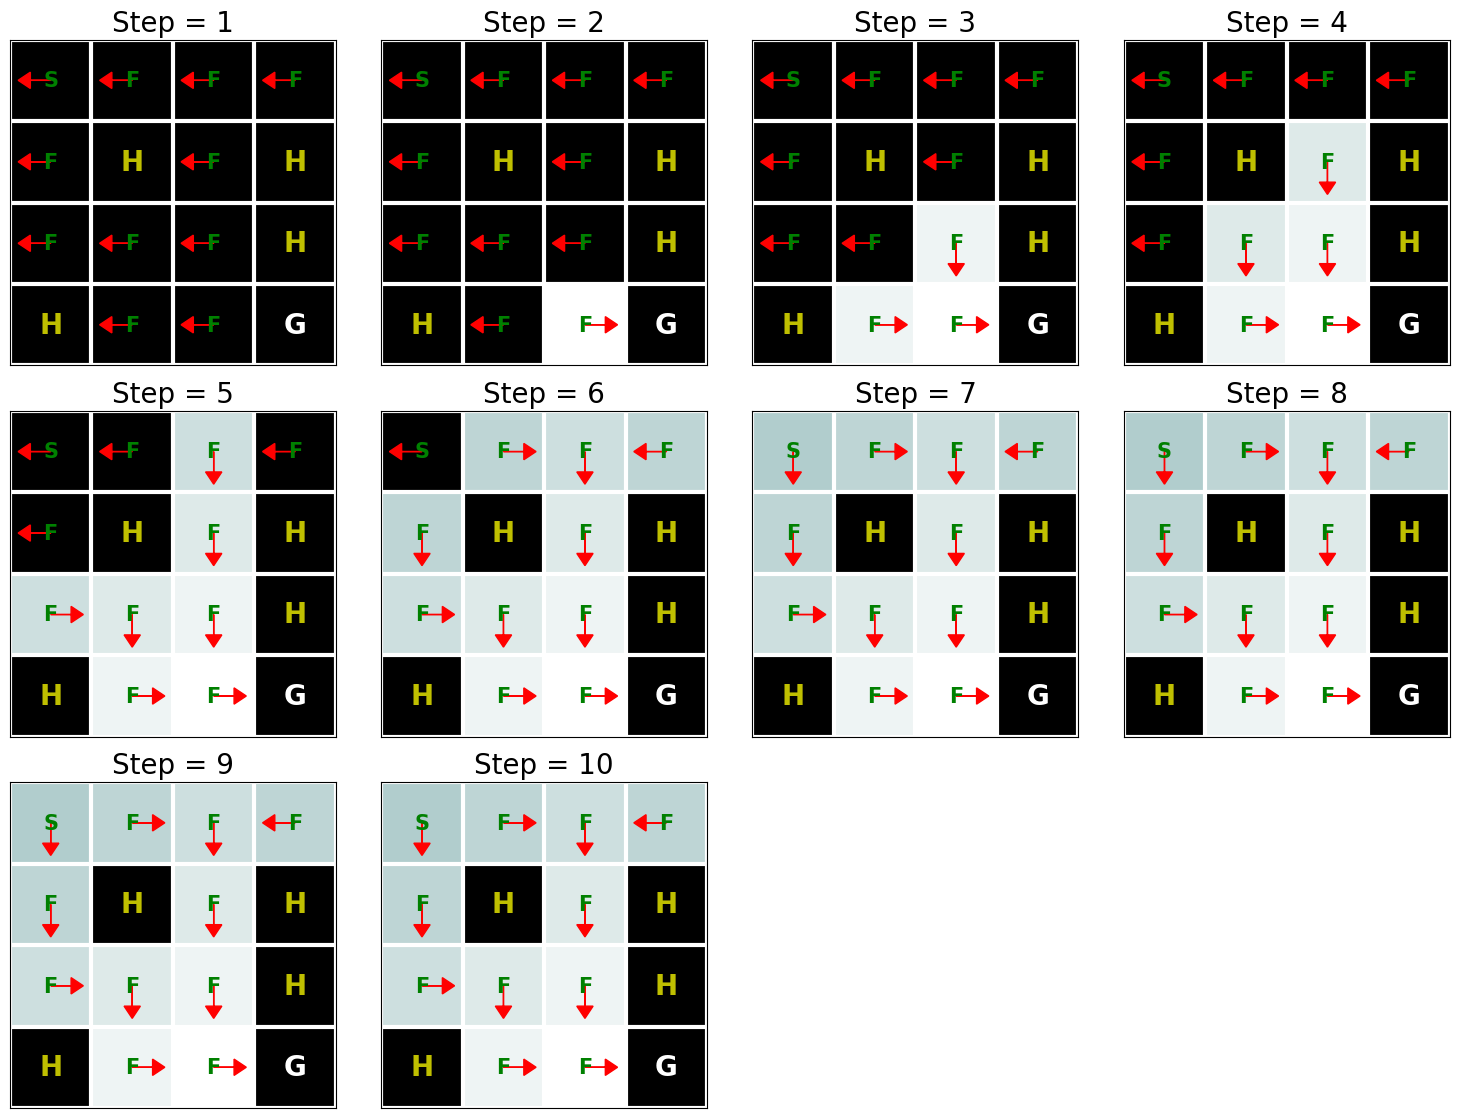

In [12]:
# assumes `env_info` contains MDP and environment-related information, and gamma is the discount factor
def value_iteration(env_info, gamma, num_iters):
    env_desc = env_info['desc'] # 2D array shows what each item means
    prob_idx = env_info['trans_prob_idx']
    nextstate_idx = env_info['nextstate_idx']
    reward_idx = env_info['reward_idx']
    num_states = env_info['num_states']
    num_actions = env_info['num_actions']
    mdp = env_info['mdp']

    V = np.zeros((num_iters + 1, num_states)) # Value fn calculation
    Q = np.zeros((num_iters + 1, num_states, num_actions)) # Action-Value calculation
    pi = np.zeros((num_iters + 1, num_states)) # Stochastic policy

    for k in range(1, num_iters+1):
        for s in range(num_states):
            for a in range(num_actions):
                # Calculate \sum_{s'} p(s' \mid s,a) [r + \gamma v_k(s')]
                for pxrds in mdp[(s,a)]:
                    # mdp(s,a): [(pi,next1,r1,d1),(p2,next2,r2,d2),...]
                    pr = pxrds[prob_idx]
                    nextstate = pxrds[nextstate_idx]
                    reward = pxrds[reward_idx]
                    Q[k,s,a] += pr * (reward+ gamma * V[k-1, nextstate])
                # Record max value and max action
                V[k,s] = np.max(Q[k,s,:])
                pi[k,s] = np.argmax(Q[k,s,:])
    d2l.show_value_function_progress(env_desc, V[:-1], pi[:-1])

value_iteration(env_info=env_info, gamma=gamma, num_iters=num_iters) # Converges at step 7

# Summary

The main idea behind the Value Iteration algorithm is to use the principle of dynamic programming to find the optimal average return obtained from a given state.

Note that implementing the Value Iteration algorithm requires that we know the Markov devision process (MDP), e.g. the transition and reward functions, completely.